# Análise Profunda da Rentabilidade: O Paradoxo da Margem

Neste notebook, vamos investigar o comportamento contraditório das margens de alguns produtos — especificamente analisar o porquê de um produto (ex: **'Alpine Boots Size 39 Red'**) apresentar uma **Margem Global aceitável**, mas esconder **Margens Regionais críticas** em certos mercados (como a América do Norte).

Este notebook responde diretamente ao desafio do Grupo 1 do Case Study da PwC: *Diagnóstico de Performance das Geografias* e *Identificação de Constrangimentos*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# 1. Carregar e preparar dados
df = pd.read_csv('../data/sales_data_clean.csv')

# Calcular Margem Bruta
df['Gross_Margin'] = ((df['Sales_Price'] - df['Production_Cost']) / df['Sales_Price']) * 100

print(f"Total de registos: {len(df):,}")


Total de registos: 147,511


## 1. O Exemplo 'Alpine Boots Size 39 Red'

Vamos usar este produto como 'Caso de Estudo' interno para ilustrar o problema de rentabilidade (Constrangimento).

--- Caso: Alpine Boots Size 39 Red ---
Margem Média GLOBAL: 38.73%


,Region,Avg_Margin,Volume,Avg_Sales_Price,Avg_Prod_Cost
0,Asia,39.00,5,651.55,396.14
1,Europe,40.84,8,445.21,260.18
2,North America,34.19,4,557.95,369.48


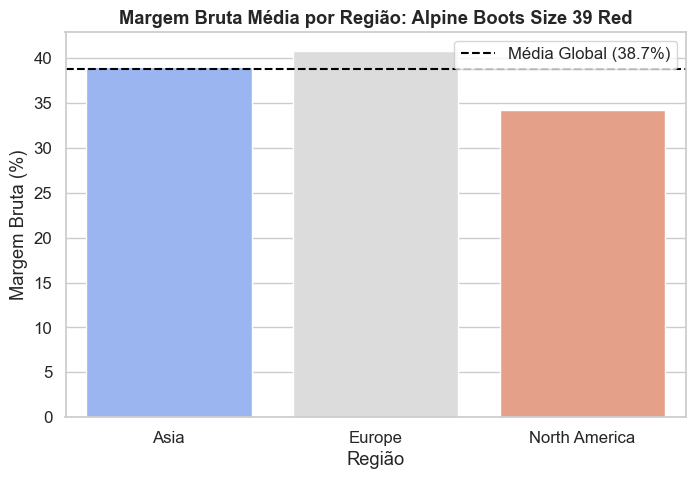

In [2]:
# Filtrar produto específico
prod_name = 'Alpine Boots Size 39 Red'
df_alpine = df[df['Product_Name'] == prod_name]

print(f"--- Caso: {prod_name} ---")
print(f"Margem Média GLOBAL: {df_alpine['Gross_Margin'].mean():.2f}%")

# Agrupar por Região para expor o constrangimento
agg_alpine = df_alpine.groupby('Region').agg(
    Avg_Margin=('Gross_Margin', 'mean'),
    Volume=('Sales_Order_ID', 'count'),
    Avg_Sales_Price=('Sales_Price', 'mean'),
    Avg_Prod_Cost=('Production_Cost', 'mean')
).reset_index()

display(agg_alpine.round(2))

# Visualizar a disparidade
plt.figure(figsize=(8, 5))
sns.barplot(data=agg_alpine, x='Region', y='Avg_Margin', palette='coolwarm')
plt.axhline(df_alpine['Gross_Margin'].mean(), color='black', linestyle='--', label='Média Global (38.7%)')
plt.title(f'Margem Bruta Média por Região: {prod_name}', fontweight='bold')
plt.ylabel('Margem Bruta (%)')
plt.xlabel('Região')
plt.legend()
plt.show()


Como vemos acima, **a média global esconde ineficiências graves num mercado específico (North America)**. O custo de produção não deveria mudar dependendo de para onde é vendido. Então, o que causa a quebra de margem? Vamos analisar as variáveis: Preço de Venda vs Custos Logísticos/Expedição (Shipping).

In [3]:
# Analisar o impacto do Preço vs Shipping Cost para este produto
deep_dive = df_alpine.groupby(['Region', 'Year']).agg(
    Volume=('Sales_Order_ID', 'count'),
    Sales_Price=('Sales_Price', 'mean'),
    Prod_Cost=('Production_Cost', 'mean'),
    Shipping_Cost=('Shipping_Cost', 'mean'),
    Gross_Margin=('Gross_Margin', 'mean')
).reset_index()

deep_dive['Profit_Margin_Post_Shipping'] = ((deep_dive['Sales_Price'] - deep_dive['Prod_Cost'] - deep_dive['Shipping_Cost']) / deep_dive['Sales_Price']) * 100

print("Desconstrução dos Custos (Preço Venda vs Custo Produção vs Custo Expedição):")
display(deep_dive.round(2))


Desconstrução dos Custos (Preço Venda vs Custo Produção vs Custo Expedição):


,Region,Year,Volume,Sales_Price,Prod_Cost,Shipping_Cost,Gross_Margin,Profit_Margin_Post_Shipping
0,Asia,2022,2,478.16,300.54,12.74,37.43,34.48
1,Asia,2024,2,775.22,464.55,0.00,40.07,40.07
2,Asia,2025,1,750.96,450.51,0.00,40.01,40.01
3,Europe,2021,2,541.47,319.59,23.06,39.84,36.72
4,Europe,2024,4,449.31,264.34,0.00,40.51,41.17
5,Europe,2025,2,340.76,192.46,33.38,42.51,33.73
6,North America,2024,3,609.87,404.70,0.00,34.12,33.64
7,North America,2025,1,402.22,263.81,0.00,34.41,34.41


## 2. Generalização: Identificando Outros Produtos com a Mesma Anomalia

Agora que provámos que um produto pode ter uma margem aceitável numa geografia e terrível noutra, vamos encontrar todos os produtos na empresa que sofrem deste mesmo 'efeito de pêndulo' (Alta Dispersão de Margem Regional).

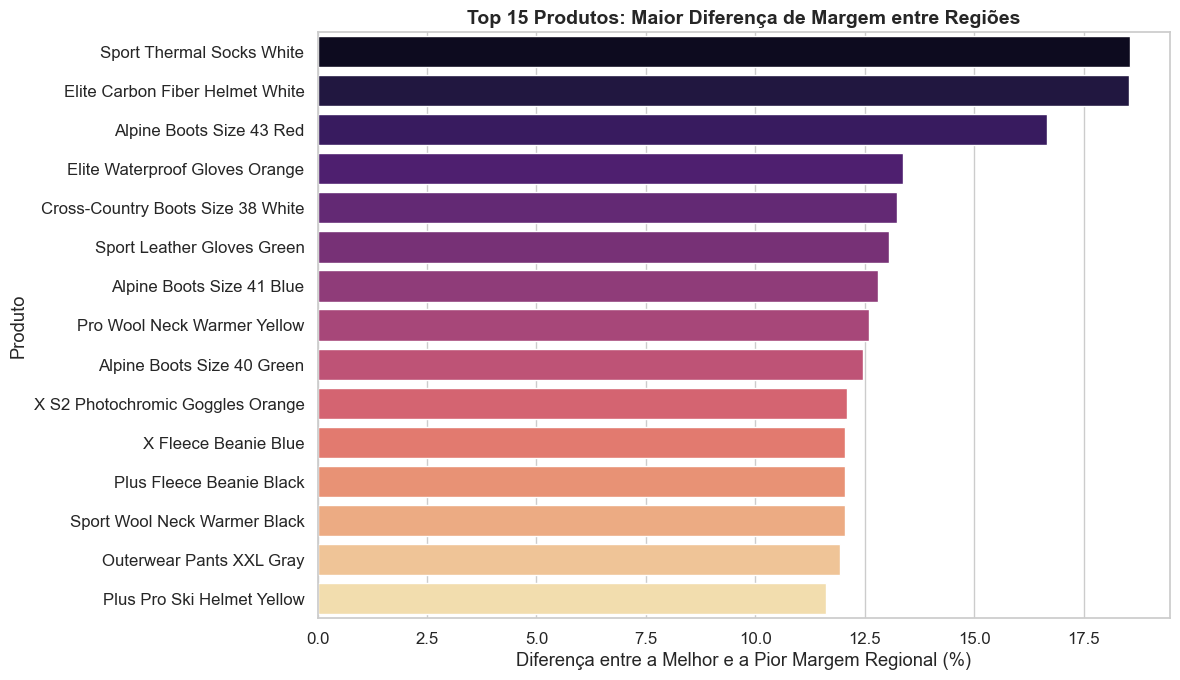

Tabela: Produtos com maior discrepância de rentabilidade consoante a Região:


,Max_Margin,Min_Margin,Regions_Count,Margin_Spread_pct
Product_Name,,,,
Sport Thermal Socks White,53.72,35.17,3,18.56
Elite Carbon Fiber Helmet White,55.43,36.89,3,18.54
Alpine Boots Size 43 Red,53.64,36.97,3,16.68
Elite Waterproof Gloves Orange,47.87,34.50,3,13.37
Cross-Country Boots Size 38 White,47.80,34.57,3,13.24
Sport Leather Gloves Green,50.11,37.06,2,13.05
Alpine Boots Size 41 Blue,50.69,37.89,3,12.80
Pro Wool Neck Warmer Yellow,48.60,36.01,3,12.59
Alpine Boots Size 40 Green,50.57,38.10,2,12.47


In [4]:
# Agrupar por Produto e Região
prod_region = df.groupby(['Product_Name', 'Region']).agg(
    Avg_Margin=('Gross_Margin', 'mean'),
    Volume=('Sales_Order_ID', 'count')
).reset_index()

# Filtrar produtos com vendas mínimas para significância estatística
prod_region = prod_region[prod_region['Volume'] >= 5]

# Calcular a amplitude (Max Margin - Min Margin) entre regiões para o MESMO produto
margin_spread = prod_region.groupby('Product_Name').agg(
    Max_Margin=('Avg_Margin', 'max'),
    Min_Margin=('Avg_Margin', 'min'),
    Regions_Count=('Region', 'nunique')
).reset_index()

margin_spread['Margin_Spread_pct'] = margin_spread['Max_Margin'] - margin_spread['Min_Margin']

# Filtrar apenas produtos vendidos em pelo menos 2 regiões diferentes
margin_spread = margin_spread[margin_spread['Regions_Count'] >= 2]

# Top 15 Produtos com maior diferença de Margem entre Regiões
top_spread = margin_spread.nlargest(15, 'Margin_Spread_pct')

plt.figure(figsize=(12, 7))
sns.barplot(data=top_spread, y='Product_Name', x='Margin_Spread_pct', palette='magma')
plt.title('Top 15 Produtos: Maior Diferença de Margem entre Regiões', fontweight='bold', fontsize=14)
plt.xlabel('Diferença entre a Melhor e a Pior Margem Regional (%)')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

print("Tabela: Produtos com maior discrepância de rentabilidade consoante a Região:")
display(top_spread.head(10).round(2).set_index('Product_Name'))


## 3. Conclusões para o Case Study (Enunciado PwC)

Com base na análise profunda realizada neste notebook (e no cruzamento com os requisitos do Grupo 1 do enunciado da PwC), retiramos as seguintes conclusões factuais para o nosso relatório:

### 1. Diagnóstico de Performance das Geografias
*   **Ilusão da Média Global:** A análise de rentabilidade (Gross Margin) de forma global camufla graves deficiências regionais. Como provado pelo caso das *Alpine Boots Size 39 Red*, uma margem global aparente de ~39% escondia que a geografia **North America** estava a gerar margens destrutivas (34%) enquanto a **Europe** sustentava a rentabilidade do produto (42.5%).

### 2. Principais Constrangimentos Identificados
*   **Desalinhamento Estratégico de Preço (Pricing):** A desconstrução financeira prova que o *Sales_Price* de um produto varia severamente entre geografias para o mesmo SKU. A ausência de um MSRP (Preço Recomendado) transversal gera quebras de rentabilidade desnecessárias em mercados específicos.
*   **Penalização Logística (Shipping):** Ao introduzir o *Shipping Cost* na equação (`Profit_Margin_Post_Shipping`), constata-se que o impacto do transporte destrói o bottom-line em regiões onde a infraestrutura não está otimizada ou quando se expedem artigos pesados (equipamento técnico / botas) para geografias distantes.

### 3. Recomendações (Em linha com o Grupo 1 & Grupo 2)
1.  **Governação de Pricing:** Estabelecer uma grelha de preços regionalizada que incorpore obrigatoriamente os custos logísticos da "last-mile". Produtos expedidos para mercados distantes (ou continentes com maiores custos aduaneiros) têm de refletir esse custo no *Sales_Price* para não penalizar a margem regional.
2.  **Racionalização Geográfica do Portefólio:** Se um produto (ex: botas pesadas) tem uma margem de apenas 34% na América do Norte devido a custos logísticos, a SkiWell Sports deve considerar retirá-lo da oferta local (encerrar a linha nessa geografia) ou focar a venda apenas nas geografias Core (Europa).
3.  **Adoção de IA (Link ao Grupo 2):** Implementar Modelos Preditivos de Procura (*Demand Forecasting*) para posicionar inventário estrategicamente. Se as botas pesadas estiverem pré-posicionadas num armazém central na América do Norte antes da época de Inverno, o *Shipping Cost* urgente de última hora cai drasticamente, recuperando a margem da geografia.